# Feature Build `_Xy_all.parquet` Artifact Review

목적: feature build 완료 산출물인 `_Xy_all.parquet` 1개를 대상으로 학습 전 데이터 품질, split drift, label separation, 신규 피처 분포를 전체 parquet 기준으로 점검한다.

사용 방법:

1. 바로 아래 `사용자 입력값` 셀에서 `EXPORT_EXPERIMENT_ID`, `RUN_ID`, `TARGET_PARQUET_PATH`를 확인 대상 파일로 맞춘다.
2. contract, manifest, feature types 경로를 직접 지정하지 않으면 같은 폴더의 sibling artifact를 자동 탐색한다.
3. 이 노트북은 `_Xy_all.parquet`를 parquet batch로 끝까지 읽어 exact summary를 계산한다.
4. 파일 복사, 승인, 재생성, overwrite는 수행하지 않는다.


In [1]:
from pathlib import Path

# ============================================================
# 사용자 입력값: 보려는 feature build 산출물이 바뀌면 이 셀만 수정
# ============================================================

LOCAL_REPO_ROOT = Path("/mnt/d/AML_git/Graph_AML").resolve()

EXPORT_EXPERIMENT_ID = "ml_04"
RUN_ID = "r00"
ARTIFACT_PREFIX = f"{EXPORT_EXPERIMENT_ID}__{RUN_ID}"

TARGET_PARQUET_PATH = (
    LOCAL_REPO_ROOT
    / "ml"
    / "ml-04"
    / "fb_outputs"
    / RUN_ID
    / f"{ARTIFACT_PREFIX}_Xy_all.parquet"
)

# 필요 시 직접 지정한다. None이면 TARGET_PARQUET_PATH와 같은 폴더에서 자동 탐색한다.
CONTRACT_PATH = None
ENCODING_MANIFEST_PATH = None
FEATURE_TYPES_PATH = None
FEATURE_INFO_PATH = None
SPLIT_SUMMARY_PATH = None

TOP_N = 30
PREVIEW_ROW_COUNT = 10
TIME_BIN_FREQ = "6h"
BATCH_SIZE = 262_144


In [2]:
from __future__ import annotations

import json
import math
import os
import re
import subprocess
from collections import Counter, defaultdict
from datetime import datetime
from pathlib import Path
from typing import Any, Optional
from zoneinfo import ZoneInfo

MPLCONFIGDIR = Path("/tmp/matplotlib-codex-cache")
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.width", 220)


In [3]:
LABEL_PREFERRED_NAMES = ["label", "target", "y", "is_laundering", "is laundering"]
SPLIT_PREFERRED_NAMES = ["split", "dataset_split", "data_split"]
TIME_PREFERRED_NAMES = ["timestamp", "time", "datetime", "event_time", "created_at"]
FORBIDDEN_FEATURE_PATTERNS = ("laundering", "pattern", "typology", "attempt")
KNOWN_NON_FEATURE_COLUMNS = {
    "tx_id",
    "timestamp",
    "Timestamp",
    "split",
    "label",
    "target",
    "y",
    "sender_account",
    "receiver_account",
    "sender_account_id",
    "receiver_account_id",
    "Account",
    "Account.1",
    "From Bank",
    "To Bank",
    "Is Laundering",
}
SPLIT_ORDER = ["train", "val", "test"]
LABEL_ORDER = [0, 1]


def normalize_name(name: str) -> str:
    return re.sub(r"[^0-9a-zA-Z]+", "_", str(name).strip().lower()).strip("_")


def normalize_bool(value: Any) -> bool:
    if pd.isna(value):
        return False
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    return str(value).strip().lower() in {"true", "1", "yes", "y", "t"}


def optional_path(value: Any) -> Optional[Path]:
    if value is None:
        return None
    text = str(value).strip()
    if text == "":
        return None
    return Path(text).expanduser().resolve()


def infer_artifact_prefix(path: Path) -> str:
    suffix = "_Xy_all.parquet"
    if not path.name.endswith(suffix):
        raise ValueError(f"TARGET_PARQUET_PATH must end with {suffix!r}: {path}")
    return path.name[: -len(suffix)]


def first_existing(paths: list[Path]) -> Optional[Path]:
    existing = [path for path in paths if path.exists()]
    return existing[0] if existing else None


def infer_sibling_artifacts(target_path: Path, prefix: str) -> dict[str, Optional[Path]]:
    base_dir = target_path.parent
    candidates = {
        "contract": [
            base_dir / f"{prefix}_fb_output_feature_contract.csv",
            base_dir / f"{prefix}_feature_contract.csv",
            base_dir / f"{prefix}_feature_contract_approve.csv",
            base_dir / f"{prefix}_fb_output_feature_contract_approve.csv",
            base_dir / f"{prefix}_ml_feature_columns_approve.csv",
            base_dir / f"{prefix}_ml_feature_columns.csv",
        ],
        "encoding_manifest": [base_dir / f"{prefix}_encoding_manifest.json"],
        "feature_types": [base_dir / f"{prefix}_feature_types.json"],
        "feature_info": [base_dir / f"{prefix}_feature_info.csv"],
        "split_summary": [base_dir / f"{prefix}_split_summary.csv"],
    }
    return {name: first_existing(path_list) for name, path_list in candidates.items()}


def load_json(path: Optional[Path]) -> Optional[dict[str, Any]]:
    if path is None:
        return None
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    if not isinstance(data, dict):
        raise TypeError(f"JSON root must be an object: {path}")
    return data


def load_csv(path: Optional[Path]) -> Optional[pd.DataFrame]:
    if path is None:
        return None
    return pd.read_csv(path)


def run_git_command(args: list[str]) -> Optional[str]:
    try:
        result = subprocess.run(
            ["git", *args],
            cwd=LOCAL_REPO_ROOT,
            check=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
        )
    except (subprocess.CalledProcessError, FileNotFoundError):
        return None
    return result.stdout.strip()


def execution_provenance(path: Path) -> pd.DataFrame:
    git_hash = run_git_command(["rev-parse", "HEAD"])
    git_status = run_git_command(["status", "--short"])
    stat = path.stat()
    return pd.DataFrame(
        [
            {
                "executed_at_kst": datetime.now(ZoneInfo("Asia/Seoul")).isoformat(timespec="seconds"),
                "target_path": str(path),
                "artifact_mtime_kst": datetime.fromtimestamp(stat.st_mtime, ZoneInfo("Asia/Seoul")).isoformat(timespec="seconds"),
                "artifact_size_mb": round(stat.st_size / 1024 / 1024, 2),
                "git_hash": git_hash,
                "git_worktree_dirty": bool(git_status),
            }
        ]
    )


def parquet_overview(path: Path) -> tuple[pq.ParquetFile, pd.DataFrame, pd.DataFrame]:
    pf = pq.ParquetFile(path)
    metadata = pf.metadata
    overview_df = pd.DataFrame(
        [
            {
                "path": str(path),
                "file_size_mb": round(path.stat().st_size / 1024 / 1024, 2),
                "num_rows": metadata.num_rows,
                "num_columns": metadata.num_columns,
                "num_row_groups": metadata.num_row_groups,
                "created_by": metadata.created_by,
            }
        ]
    )
    schema_rows = []
    for idx, field in enumerate(pf.schema_arrow):
        schema_rows.append(
            {
                "idx": idx,
                "column_name": field.name,
                "arrow_type": str(field.type),
                "nullable": field.nullable,
            }
        )
    return pf, overview_df, pd.DataFrame(schema_rows)


def detect_special_columns(columns: list[str]) -> dict[str, list[str]]:
    label_normalized = {normalize_name(x) for x in LABEL_PREFERRED_NAMES}
    split_normalized = {normalize_name(x) for x in SPLIT_PREFERRED_NAMES}
    time_normalized = {normalize_name(x) for x in TIME_PREFERRED_NAMES}
    labels = []
    splits = []
    times = []
    forbidden = []
    for col in columns:
        normalized = normalize_name(col)
        if normalized in label_normalized:
            labels.append(col)
        if normalized in split_normalized:
            splits.append(col)
        if normalized in time_normalized or "timestamp" in normalized:
            times.append(col)
        if any(pattern in normalized for pattern in FORBIDDEN_FEATURE_PATTERNS):
            forbidden.append(col)
    return {"label": labels, "split": splits, "time": times, "forbidden": forbidden}


def choose_preferred_column(candidates: list[str], preferred_names: list[str]) -> Optional[str]:
    if not candidates:
        return None
    by_normalized = {}
    for col in candidates:
        by_normalized.setdefault(normalize_name(col), col)
    for name in preferred_names:
        normalized = normalize_name(name)
        if normalized in by_normalized:
            return by_normalized[normalized]
    return candidates[0]


def feature_types_columns(feature_types: Optional[dict[str, Any]]) -> list[str]:
    if feature_types is None:
        return []
    raw = feature_types.get("feature_types", feature_types)
    if isinstance(raw, dict):
        return list(raw.keys())
    return []


def manifest_feature_columns(manifest: Optional[dict[str, Any]]) -> list[str]:
    if manifest is None:
        return []
    columns = manifest.get("feature_columns", [])
    if isinstance(columns, list):
        return [str(col) for col in columns]
    return []


def contract_selected_columns(contract_df: Optional[pd.DataFrame]) -> list[str]:
    if contract_df is None:
        return []
    required = {"column_name", "used_in_ml"}
    if not required.issubset(contract_df.columns):
        return []
    mask = contract_df["used_in_ml"].map(normalize_bool)
    return contract_df.loc[mask, "column_name"].dropna().astype(str).tolist()


def infer_feature_columns(
    schema_columns: list[str],
    contract_df: Optional[pd.DataFrame],
    feature_types: Optional[dict[str, Any]],
    manifest: Optional[dict[str, Any]],
) -> tuple[list[str], str]:
    selected = contract_selected_columns(contract_df)
    if selected:
        return selected, "contract.used_in_ml"
    from_feature_types = feature_types_columns(feature_types)
    if from_feature_types:
        return from_feature_types, "feature_types"
    from_manifest = manifest_feature_columns(manifest)
    if from_manifest:
        return from_manifest, "encoding_manifest.feature_columns"
    inferred = []
    known_non_feature_normalized = {normalize_name(x) for x in KNOWN_NON_FEATURE_COLUMNS}
    for col in schema_columns:
        normalized = normalize_name(col)
        is_known_non_feature = col in KNOWN_NON_FEATURE_COLUMNS or normalized in known_non_feature_normalized
        is_forbidden = any(pattern in normalized for pattern in FORBIDDEN_FEATURE_PATTERNS)
        if not is_known_non_feature and not is_forbidden:
            inferred.append(col)
    return inferred, "schema_inferred"


def selected_contract_frame(contract_df: Optional[pd.DataFrame], selected_columns: list[str]) -> pd.DataFrame:
    if contract_df is None:
        return pd.DataFrame({"column_name": selected_columns})
    selected_set = set(selected_columns)
    return contract_df.loc[contract_df["column_name"].astype(str).isin(selected_set)].copy()


def feature_group_map(contract_df: Optional[pd.DataFrame], feature_columns: list[str]) -> dict[str, str]:
    if contract_df is not None and {"column_name", "feature_group"}.issubset(contract_df.columns):
        group_series = contract_df.set_index("column_name")["feature_group"]
        return {col: str(group_series.get(col, "unknown") or "unknown") for col in feature_columns}
    return {col: str(col).split("__", 1)[0] if "__" in str(col) else "unknown" for col in feature_columns}


def signed_log1p_array(values: np.ndarray) -> np.ndarray:
    return np.sign(values) * np.log1p(np.abs(values))


def safe_ratio(numerator: float, denominator: float) -> float:
    if denominator == 0 or pd.isna(denominator):
        return np.nan
    return numerator / denominator


def read_parquet_head(path: Path, columns: list[str], row_count: int) -> pd.DataFrame:
    pf = pq.ParquetFile(path)
    pieces = []
    remaining = row_count
    for batch in pf.iter_batches(batch_size=min(BATCH_SIZE, max(1, remaining)), columns=columns):
        pieces.append(batch.to_pandas())
        remaining -= batch.num_rows
        if remaining <= 0:
            break
    if not pieces:
        return pd.DataFrame(columns=columns)
    return pd.concat(pieces, ignore_index=True).head(row_count)


In [4]:
target_path = Path(TARGET_PARQUET_PATH).expanduser().resolve()
if not target_path.exists():
    raise FileNotFoundError(f"TARGET_PARQUET_PATH not found: {target_path}")

artifact_prefix = infer_artifact_prefix(target_path)
auto_paths = infer_sibling_artifacts(target_path, artifact_prefix)
artifact_paths = {
    "contract": optional_path(CONTRACT_PATH) or auto_paths["contract"],
    "encoding_manifest": optional_path(ENCODING_MANIFEST_PATH) or auto_paths["encoding_manifest"],
    "feature_types": optional_path(FEATURE_TYPES_PATH) or auto_paths["feature_types"],
    "feature_info": optional_path(FEATURE_INFO_PATH) or auto_paths["feature_info"],
    "split_summary": optional_path(SPLIT_SUMMARY_PATH) or auto_paths["split_summary"],
}

pf, overview_df, schema_df = parquet_overview(target_path)
schema_columns = schema_df["column_name"].tolist()
special_columns = detect_special_columns(schema_columns)
label_col = choose_preferred_column(special_columns["label"], LABEL_PREFERRED_NAMES)
split_col = choose_preferred_column(special_columns["split"], SPLIT_PREFERRED_NAMES)
time_col = choose_preferred_column(special_columns["time"], TIME_PREFERRED_NAMES)

if label_col is None:
    raise ValueError("No label-like column detected in parquet schema")
if split_col is None:
    raise ValueError("No split-like column detected in parquet schema")
if time_col is None:
    raise ValueError("No timestamp-like column detected in parquet schema")

display(Markdown("## 1. Run provenance"))
display(execution_provenance(target_path))

display(Markdown("## 2. Target parquet metadata"))
display(overview_df)

display(Markdown("## 3. Auto-resolved sibling artifacts"))
display(
    pd.DataFrame(
        [
            {"artifact": key, "path": str(path) if path is not None else None, "exists": bool(path and path.exists())}
            for key, path in artifact_paths.items()
        ]
    )
)

display(Markdown("## 4. Detected control columns"))
display(
    pd.DataFrame(
        [
            {"role": "label", "selected_column": label_col, "candidates": special_columns["label"]},
            {"role": "split", "selected_column": split_col, "candidates": special_columns["split"]},
            {"role": "timestamp", "selected_column": time_col, "candidates": special_columns["time"]},
            {"role": "forbidden_name_pattern", "selected_column": None, "candidates": special_columns["forbidden"]},
        ]
    )
)


## 1. Run provenance

,executed_at_kst,target_path,artifact_mtime_kst,artifact_size_mb,git_hash,git_worktree_dirty
0,2026-05-28T13:48:00+09:00,/mnt/d/AML_git/Graph_AML/ml/ml-04/fb_outputs/r00/ml_04__r00_Xy_all.parquet,2026-05-28T12:21:22+09:00,2672.19,1c4307abfa457a2f25a963fa12940ef56bacee7e,True


## 2. Target parquet metadata

,path,file_size_mb,num_rows,num_columns,num_row_groups,created_by
0,/mnt/d/AML_git/Graph_AML/ml/ml-04/fb_outputs/r00/ml_04__r00_Xy_all.parquet,2672.19,5077237,221,5,parquet-cpp-arrow version 14.0.2


## 3. Auto-resolved sibling artifacts

,artifact,path,exists
0,contract,/mnt/d/AML_git/Graph_AML/ml/ml-04/fb_outputs/r00/ml_04__r00_fb_output_feature_contract.csv,True
1,encoding_manifest,/mnt/d/AML_git/Graph_AML/ml/ml-04/fb_outputs/r00/ml_04__r00_encoding_manifest.json,True
2,feature_types,/mnt/d/AML_git/Graph_AML/ml/ml-04/fb_outputs/r00/ml_04__r00_feature_types.json,True
3,feature_info,/mnt/d/AML_git/Graph_AML/ml/ml-04/fb_outputs/r00/ml_04__r00_feature_info.csv,True
4,split_summary,/mnt/d/AML_git/Graph_AML/ml/ml-04/fb_outputs/r00/ml_04__r00_split_summary.csv,True


## 4. Detected control columns

,role,selected_column,candidates
0,label,label,"[label, Is Laundering]"
1,split,split,[split]
2,timestamp,timestamp,"[timestamp, Timestamp]"
3,forbidden_name_pattern,None,[Is Laundering]


In [5]:
contract_df = load_csv(artifact_paths["contract"])
feature_info_df = load_csv(artifact_paths["feature_info"])
split_summary_df = load_csv(artifact_paths["split_summary"])
encoding_manifest = load_json(artifact_paths["encoding_manifest"])
feature_types = load_json(artifact_paths["feature_types"])

feature_columns, feature_source = infer_feature_columns(schema_columns, contract_df, feature_types, encoding_manifest)
feature_columns_in_parquet = [col for col in feature_columns if col in schema_columns]
missing_feature_columns = [col for col in feature_columns if col not in schema_columns]
forbidden_selected = [col for col in feature_columns if col in special_columns["forbidden"]]
selected_contract_df = selected_contract_frame(contract_df, feature_columns_in_parquet)

if contract_df is not None and "build_action" in contract_df.columns:
    new_feature_columns = selected_contract_df.loc[
        selected_contract_df["build_action"].astype("string").str.lower().eq("build"),
        "column_name",
    ].dropna().astype(str).tolist()
else:
    new_feature_columns = []

review_feature_columns = new_feature_columns if new_feature_columns else feature_columns_in_parquet
pair_window_columns = []
if not selected_contract_df.empty and "feature_spec_name" in selected_contract_df.columns:
    pair_window_columns = selected_contract_df.loc[
        selected_contract_df["column_name"].astype(str).isin(review_feature_columns)
        & selected_contract_df["feature_spec_name"].astype("string").eq("pair_window"),
        "column_name",
    ].astype(str).tolist()
if not pair_window_columns:
    pair_window_columns = [col for col in review_feature_columns if "__w" in col and "pair__" in col]

summary_rows = [
    {"item": "feature_source", "value": feature_source},
    {"item": "feature_columns", "value": len(feature_columns)},
    {"item": "feature_columns_in_parquet", "value": len(feature_columns_in_parquet)},
    {"item": "missing_feature_columns", "value": len(missing_feature_columns)},
    {"item": "selected_new_build_features", "value": len(new_feature_columns)},
    {"item": "review_feature_scope", "value": "new build features" if new_feature_columns else "all selected features"},
    {"item": "pair_window_features", "value": len(pair_window_columns)},
    {"item": "forbidden_columns_selected_as_features", "value": forbidden_selected},
]

display(Markdown("## 5. Feature contract summary"))
display(pd.DataFrame(summary_rows))

if missing_feature_columns:
    display(Markdown("### Missing feature columns"))
    display(pd.DataFrame({"missing_feature_column": missing_feature_columns}))

if contract_df is not None:
    display(Markdown("### Contract row counts"))
    contract_counts = []
    for col in ["used_in_ml", "build_action", "build_in_fb", "encoding", "feature_group", "leakage_risk", "review_status"]:
        if col in contract_df.columns:
            vc = contract_df[col].astype("string").fillna("<NA>").value_counts(dropna=False).reset_index()
            vc.columns = [col, "count"]
            vc.insert(0, "field", col)
            contract_counts.append(vc)
    if contract_counts:
        display(pd.concat(contract_counts, ignore_index=True))

    display(Markdown("### Selected feature count by group"))
    selected_group_counts = selected_contract_df["feature_group"].astype("string").fillna("unknown").value_counts().reset_index()
    selected_group_counts.columns = ["feature_group", "selected_feature_count"]
    display(selected_group_counts)

    if new_feature_columns:
        display(Markdown("### Newly built selected features"))
        preview_cols = [
            col
            for col in ["column_name", "feature_group", "feature_spec_name", "leakage_risk", "review_status"]
            if col in selected_contract_df.columns
        ]
        display(selected_contract_df.loc[selected_contract_df["column_name"].isin(new_feature_columns), preview_cols])

if feature_info_df is not None and not feature_info_df.empty:
    display(Markdown("### Feature info for newly built features"))
    info_cols = [
        col
        for col in [
            "column_name",
            "rows",
            "missing_rate",
            "inf_count",
            "zero_rate",
            "unique_count",
            "near_zero_variance",
            "computational_cost",
            "leakage_policy",
        ]
        if col in feature_info_df.columns
    ]
    info_focus = feature_info_df.loc[feature_info_df["column_name"].isin(review_feature_columns), info_cols]
    display(info_focus.sort_values(["zero_rate", "column_name"], ascending=[False, True]).head(TOP_N))

if split_summary_df is not None:
    display(Markdown("### Split summary artifact"))
    display(split_summary_df)


## 5. Feature contract summary

,item,value
0,feature_source,contract.used_in_ml
1,feature_columns,186
2,feature_columns_in_parquet,186
3,missing_feature_columns,0
4,selected_new_build_features,39
5,review_feature_scope,new build features
6,pair_window_features,34
7,forbidden_columns_selected_as_features,[]


### Contract row counts

,field,used_in_ml,count,build_action,build_in_fb,encoding,feature_group,leakage_risk,review_status
0,used_in_ml,True,186,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,used_in_ml,False,35,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,build_action,<NA>,182,carry_forward,<NA>,<NA>,<NA>,<NA>,<NA>
3,build_action,<NA>,39,build,<NA>,<NA>,<NA>,<NA>,<NA>
4,build_in_fb,<NA>,182,<NA>,False,<NA>,<NA>,<NA>,<NA>
5,build_in_fb,<NA>,39,<NA>,True,<NA>,<NA>,<NA>,<NA>
6,encoding,<NA>,221,<NA>,<NA>,passthrough,<NA>,<NA>,<NA>
7,feature_group,<NA>,147,<NA>,<NA>,<NA>,parent_ml03_selected,<NA>,<NA>
8,feature_group,<NA>,38,<NA>,<NA>,<NA>,pair,<NA>,<NA>
9,feature_group,<NA>,27,<NA>,<NA>,<NA>,source_parquet_inventory,<NA>,<NA>


### Selected feature count by group

...

,column_name,feature_group,feature_spec_name,leakage_risk,review_status
182,pair__sender_receiver__forward__tx_count__count__w1h,pair,pair_window,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved
183,pair__sender_receiver__forward__amount__sum__w1h,pair,pair_window,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved
184,pair__sender_receiver__forward__tx_count__count__w6h,pair,pair_window,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved
185,pair__sender_receiver__forward__amount__sum__w6h,pair,pair_window,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved
186,pair__sender_receiver__forward__tx_count__count__w1d,pair,pair_window,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved
187,pair__sender_receiver__forward__amount__sum__w1d,pair,pair_window,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved
188,pair__sender_receiver__forward__tx_count__count__w3d,pair,pair_window,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved
189,pair__sender_receiver__forward__amount__sum__w3d,pair,pair_window,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved
190,pair__sender_receiver__forward__tx_count__count__w7d,pair,pair_window,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved
191,pair__sender_receiver__forward__amount__sum__w7d,pair,pair_window,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved


### Feature info for newly built features

,column_name,rows,missing_rate,inf_count,zero_rate,unique_count,near_zero_variance,computational_cost,leakage_policy
23,pair__sender_receiver__bidirectional__amount_ratio__w1d,5077237,0.0,0,0.960233,162,False,medium,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded
19,pair__sender_receiver__reverse__exists__w1d,5077237,0.0,0,0.960051,2,False,medium,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded
20,pair__sender_receiver__reverse__tx_count__count__w1d,5077237,0.0,0,0.960051,16,False,medium,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded
28,pair__sender_receiver__bidirectional__amount_ratio__w3d,5077237,0.0,0,0.956860,442,False,medium,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded
24,pair__sender_receiver__reverse__exists__w3d,5077237,0.0,0,0.956440,2,False,medium,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded
25,pair__sender_receiver__reverse__tx_count__count__w3d,5077237,0.0,0,0.956440,32,False,medium,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded
33,pair__sender_receiver__bidirectional__amount_ratio__w7d,5077237,0.0,0,0.956278,929,False,medium,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded
29,pair__sender_receiver__reverse__exists__w7d,5077237,0.0,0,0.955601,2,False,medium,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded
30,pair__sender_receiver__reverse__tx_count__count__w7d,5077237,0.0,0,0.955601,65,False,medium,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded
36,pair__sender_receiver__current__is_self_loop,5077237,0.0,0,0.883634,2,False,low,current-row-only; no history or future rows used


### Split summary artifact

,split,rows,timestamp_min,timestamp_max,label_0_count,label_1_count,positive_rate
0,train,3046186,2022-09-01 00:00:00,2022-09-06 13:33:00,3043890,2296,0.000754
1,val,1015633,2022-09-06 13:34:00,2022-09-08 16:09:00,1014550,1083,0.001066
2,test,1015418,2022-09-08 16:10:00,2022-09-10 23:59:00,1014275,1143,0.001126


In [6]:
display(Markdown("## 6. Full artifact scan"))

group_by_feature = feature_group_map(contract_df, feature_columns_in_parquet)
groups = sorted(set(group_by_feature.values()))
group_index = {group: idx for idx, group in enumerate(groups)}
review_index = {col: idx for idx, col in enumerate(review_feature_columns)}
selected_index = {col: idx for idx, col in enumerate(feature_columns_in_parquet)}

split_label_counter: Counter[tuple[str, int]] = Counter()
split_counter: Counter[str] = Counter()
label_counter: Counter[int] = Counter()
time_counter: Counter[tuple[pd.Timestamp, str]] = Counter()
time_positive_counter: Counter[tuple[pd.Timestamp, str]] = Counter()

review_stats: dict[tuple[str, Any], dict[str, Any]] = {}
for split in [*SPLIT_ORDER, "all"]:
    review_stats[("split", split)] = {
        "n": 0,
        "sum": np.zeros(len(review_feature_columns), dtype=np.float64),
        "sumsq": np.zeros(len(review_feature_columns), dtype=np.float64),
        "missing": np.zeros(len(review_feature_columns), dtype=np.int64),
        "inf": np.zeros(len(review_feature_columns), dtype=np.int64),
        "zero": np.zeros(len(review_feature_columns), dtype=np.int64),
        "nonzero": np.zeros(len(review_feature_columns), dtype=np.int64),
    }
for label in LABEL_ORDER:
    review_stats[("label", label)] = {
        "n": 0,
        "sum": np.zeros(len(review_feature_columns), dtype=np.float64),
        "sumsq": np.zeros(len(review_feature_columns), dtype=np.float64),
        "missing": np.zeros(len(review_feature_columns), dtype=np.int64),
        "inf": np.zeros(len(review_feature_columns), dtype=np.int64),
        "zero": np.zeros(len(review_feature_columns), dtype=np.int64),
        "nonzero": np.zeros(len(review_feature_columns), dtype=np.int64),
    }

group_split_stats = {
    (group, split): {"cells": 0, "missing": 0, "inf": 0, "zero": 0, "nonzero": 0}
    for group in groups
    for split in SPLIT_ORDER
}

corr_columns = pair_window_columns
corr_n = 0
corr_sum = np.zeros(len(corr_columns), dtype=np.float64)
corr_cross = np.zeros((len(corr_columns), len(corr_columns)), dtype=np.float64)

scan_columns = list(dict.fromkeys([split_col, label_col, time_col, *feature_columns_in_parquet]))
scan_pf = pq.ParquetFile(target_path)
for batch in scan_pf.iter_batches(batch_size=BATCH_SIZE, columns=scan_columns):
    df = batch.to_pandas()
    split_values = df[split_col].astype("string").fillna("<NA>").to_numpy()
    label_values = pd.to_numeric(df[label_col], errors="coerce").fillna(-1).astype("int8").to_numpy()
    time_values = pd.to_datetime(df[time_col], errors="coerce")
    time_bins = time_values.dt.floor(TIME_BIN_FREQ)

    split_label_frame = pd.DataFrame({"split": split_values, "label": label_values})
    for row in split_label_frame.value_counts().reset_index(name="rows").itertuples(index=False):
        split_name = str(row.split)
        label_value = int(row.label)
        count = int(row.rows)
        split_label_counter[(split_name, label_value)] += count
        split_counter[split_name] += count
        label_counter[label_value] += count

    time_frame = pd.DataFrame({"time_bin": time_bins, "split": split_values, "label": label_values}).dropna(subset=["time_bin"])
    if not time_frame.empty:
        time_counts = time_frame.groupby(["time_bin", "split"], observed=True).size()
        time_pos_counts = time_frame.loc[time_frame["label"].eq(1)].groupby(["time_bin", "split"], observed=True).size()
        for key, count in time_counts.items():
            time_counter[(pd.Timestamp(key[0]), str(key[1]))] += int(count)
        for key, count in time_pos_counts.items():
            time_positive_counter[(pd.Timestamp(key[0]), str(key[1]))] += int(count)

    review_matrix = (
        df[review_feature_columns]
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(dtype=np.float64, na_value=np.nan)
    )
    review_missing = np.isnan(review_matrix)
    review_inf = np.isinf(review_matrix)
    review_finite = ~(review_missing | review_inf)
    review_clean = np.where(review_finite, review_matrix, 0.0)

    def update_review_stats(key: tuple[str, Any], mask: np.ndarray) -> None:
        if not mask.any():
            return
        x = review_clean[mask]
        finite = review_finite[mask]
        missing = review_missing[mask]
        inf = review_inf[mask]
        st = review_stats[key]
        st["n"] += int(mask.sum())
        st["sum"] += x.sum(axis=0)
        st["sumsq"] += np.square(x).sum(axis=0)
        st["missing"] += missing.sum(axis=0)
        st["inf"] += inf.sum(axis=0)
        st["zero"] += ((x == 0) & finite).sum(axis=0)
        st["nonzero"] += ((x != 0) & finite).sum(axis=0)

    update_review_stats(("split", "all"), np.ones(len(df), dtype=bool))
    for split in SPLIT_ORDER:
        update_review_stats(("split", split), split_values == split)
    for label in LABEL_ORDER:
        update_review_stats(("label", label), label_values == label)

    selected_matrix = (
        df[feature_columns_in_parquet]
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(dtype=np.float64, na_value=np.nan)
    )
    selected_missing = np.isnan(selected_matrix)
    selected_inf = np.isinf(selected_matrix)
    selected_finite = ~(selected_missing | selected_inf)
    selected_clean = np.where(selected_finite, selected_matrix, 0.0)
    for group in groups:
        group_cols = [selected_index[col] for col in feature_columns_in_parquet if group_by_feature[col] == group]
        if not group_cols:
            continue
        group_missing = selected_missing[:, group_cols]
        group_inf = selected_inf[:, group_cols]
        group_finite = selected_finite[:, group_cols]
        group_clean = selected_clean[:, group_cols]
        for split in SPLIT_ORDER:
            mask = split_values == split
            if not mask.any():
                continue
            key = (group, split)
            st = group_split_stats[key]
            row_count = int(mask.sum())
            st["cells"] += row_count * len(group_cols)
            st["missing"] += int(group_missing[mask].sum())
            st["inf"] += int(group_inf[mask].sum())
            st["zero"] += int(((group_clean[mask] == 0) & group_finite[mask]).sum())
            st["nonzero"] += int(((group_clean[mask] != 0) & group_finite[mask]).sum())

    if corr_columns:
        corr_matrix_batch = (
            df[corr_columns]
            .apply(pd.to_numeric, errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0.0)
            .to_numpy(dtype=np.float64)
        )
        corr_n += corr_matrix_batch.shape[0]
        corr_sum += corr_matrix_batch.sum(axis=0)
        corr_cross += corr_matrix_batch.T @ corr_matrix_batch

split_label_df = (
    pd.DataFrame(
        [
            {"split": split, "label": label, "rows": count}
            for (split, label), count in split_label_counter.items()
        ]
    )
    .sort_values(["split", "label"])
    .reset_index(drop=True)
)
split_summary_exact_df = split_label_df.pivot_table(index="split", columns="label", values="rows", fill_value=0, aggfunc="sum")
for label in LABEL_ORDER:
    if label not in split_summary_exact_df.columns:
        split_summary_exact_df[label] = 0
split_summary_exact_df = split_summary_exact_df[LABEL_ORDER].reset_index()
split_summary_exact_df["rows"] = split_summary_exact_df[LABEL_ORDER].sum(axis=1)
split_summary_exact_df["positive_rate"] = split_summary_exact_df[1] / split_summary_exact_df["rows"].replace(0, np.nan)
split_summary_exact_df = split_summary_exact_df[["split", "rows", 0, 1, "positive_rate"]]
split_summary_exact_df.columns = ["split", "rows", "label_0_count", "label_1_count", "positive_rate"]

review_split_rows = []
for col_idx, col in enumerate(review_feature_columns):
    row = {"column_name": col}
    for split in SPLIT_ORDER:
        st = review_stats[("split", split)]
        n = st["n"]
        mean_value = st["sum"][col_idx] / n if n else np.nan
        row[f"{split}_mean"] = mean_value
        row[f"{split}_nonzero_rate"] = st["nonzero"][col_idx] / n if n else np.nan
        row[f"{split}_zero_rate"] = st["zero"][col_idx] / n if n else np.nan
        row[f"{split}_missing_rate"] = st["missing"][col_idx] / n if n else np.nan
    train_mean = row.get("train_mean", np.nan)
    val_mean = row.get("val_mean", np.nan)
    test_mean = row.get("test_mean", np.nan)
    row["val_train_mean_ratio"] = safe_ratio(val_mean, train_mean)
    row["test_train_mean_ratio"] = safe_ratio(test_mean, train_mean)
    mean_logs = signed_log1p_array(np.array([train_mean, val_mean, test_mean], dtype=np.float64))
    row["max_abs_signed_log1p_mean_gap_vs_train"] = float(np.nanmax(np.abs(mean_logs - mean_logs[0])))
    nonzero_rates = [row.get(f"{split}_nonzero_rate", np.nan) for split in SPLIT_ORDER]
    row["max_nonzero_rate_gap"] = float(np.nanmax(nonzero_rates) - np.nanmin(nonzero_rates))
    review_split_rows.append(row)
review_split_df = pd.DataFrame(review_split_rows)

review_label_rows = []
for col_idx, col in enumerate(review_feature_columns):
    st0 = review_stats[("label", 0)]
    st1 = review_stats[("label", 1)]
    n0 = st0["n"]
    n1 = st1["n"]
    mean0 = st0["sum"][col_idx] / n0 if n0 else np.nan
    mean1 = st1["sum"][col_idx] / n1 if n1 else np.nan
    var0 = st0["sumsq"][col_idx] / n0 - mean0**2 if n0 else np.nan
    var1 = st1["sumsq"][col_idx] / n1 - mean1**2 if n1 else np.nan
    pooled = math.sqrt(max((var0 + var1) / 2, 0.0)) if np.isfinite(var0) and np.isfinite(var1) else np.nan
    smd = (mean1 - mean0) / pooled if pooled and pooled > 0 else np.nan
    nonzero0 = st0["nonzero"][col_idx] / n0 if n0 else np.nan
    nonzero1 = st1["nonzero"][col_idx] / n1 if n1 else np.nan
    review_label_rows.append(
        {
            "column_name": col,
            "mean_label0": mean0,
            "mean_label1": mean1,
            "mean_ratio_label1_over_label0": safe_ratio(mean1, mean0),
            "std_mean_diff": smd,
            "nonzero_rate_label0": nonzero0,
            "nonzero_rate_label1": nonzero1,
            "nonzero_rate_diff_l1_l0": nonzero1 - nonzero0,
        }
    )
review_label_df = pd.DataFrame(review_label_rows)

feature_quality_rows = []
all_review_stats = review_stats[("split", "all")]
for col_idx, col in enumerate(review_feature_columns):
    n = all_review_stats["n"]
    feature_quality_rows.append(
        {
            "column_name": col,
            "missing_rate": all_review_stats["missing"][col_idx] / n if n else np.nan,
            "inf_count": int(all_review_stats["inf"][col_idx]),
            "zero_rate": all_review_stats["zero"][col_idx] / n if n else np.nan,
            "nonzero_rate": all_review_stats["nonzero"][col_idx] / n if n else np.nan,
        }
    )
feature_quality_df = pd.DataFrame(feature_quality_rows)

review_rank_df = (
    feature_quality_df.merge(review_split_df, on="column_name", how="left")
    .merge(review_label_df, on="column_name", how="left")
)
review_rank_df["review_priority_score"] = review_rank_df[
    ["zero_rate", "max_abs_signed_log1p_mean_gap_vs_train", "max_nonzero_rate_gap", "std_mean_diff", "nonzero_rate_diff_l1_l0"]
].abs().fillna(0).sum(axis=1)
top_review_features = review_rank_df.sort_values("review_priority_score", ascending=False)["column_name"].head(10).tolist()

heatmap_rows = []
for (group, split), st in group_split_stats.items():
    cells = st["cells"]
    heatmap_rows.append(
        {
            "feature_group": group,
            "split": split,
            "missing_rate": st["missing"] / cells if cells else np.nan,
            "inf_rate": st["inf"] / cells if cells else np.nan,
            "zero_rate": st["zero"] / cells if cells else np.nan,
            "nonzero_rate": st["nonzero"] / cells if cells else np.nan,
        }
    )
group_split_quality_df = pd.DataFrame(heatmap_rows)

time_rows = []
for key, rows in time_counter.items():
    positive_rows = time_positive_counter.get(key, 0)
    time_rows.append(
        {
            "time_bin": key[0],
            "split": key[1],
            "rows": rows,
            "positive_rows": positive_rows,
            "positive_rate": positive_rows / rows if rows else np.nan,
        }
    )
time_series_df = pd.DataFrame(time_rows).sort_values(["time_bin", "split"]).reset_index(drop=True)

corr_df = pd.DataFrame()
if corr_columns and corr_n > 1:
    corr_mean = corr_sum / corr_n
    corr_cov = corr_cross / corr_n - np.outer(corr_mean, corr_mean)
    corr_std = np.sqrt(np.clip(np.diag(corr_cov), 0, None))
    denom = np.outer(corr_std, corr_std)
    with np.errstate(divide="ignore", invalid="ignore"):
        corr = np.divide(corr_cov, denom, out=np.zeros_like(corr_cov), where=denom > 0)
    corr = np.clip(corr, -1, 1)
    corr_df = pd.DataFrame(corr, index=corr_columns, columns=corr_columns)

display(Markdown("### Exact split/label counts"))
display(split_summary_exact_df)

display(Markdown("### Top split drift features"))
display(
    review_split_df.sort_values("max_abs_signed_log1p_mean_gap_vs_train", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

display(Markdown("### Top label separation features"))
display(
    review_label_df.reindex(review_label_df["std_mean_diff"].abs().sort_values(ascending=False).index)
    .head(TOP_N)
    .reset_index(drop=True)
)

display(Markdown("### Top review priority features"))
display(review_rank_df.sort_values("review_priority_score", ascending=False).head(TOP_N).reset_index(drop=True))


## 6. Full artifact scan

### Exact split/label counts

,split,rows,label_0_count,label_1_count,positive_rate
0,test,1015418,1014275,1143,0.001126
1,train,3046186,3043890,2296,0.000754
2,val,1015633,1014550,1083,0.001066


### Top split drift features

,column_name,train_mean,train_nonzero_rate,train_zero_rate,train_missing_rate,val_mean,val_nonzero_rate,val_zero_rate,val_missing_rate,test_mean,test_nonzero_rate,test_zero_rate,test_missing_rate,val_train_mean_ratio,test_train_mean_ratio,max_abs_signed_log1p_mean_gap_vs_train,max_nonzero_rate_gap
0,pair__sender_receiver__forward__amount__cur_vs_mean_ratio__w7d,1.275017e+03,0.688570,0.311430,0.0,7.273531e+00,0.961109,0.038891,0.0,2.311142e+00,0.899474,0.100526,0.0,0.005705,0.001813,5.954205,0.272539
1,pair__sender_receiver__forward__amount__cur_vs_mean_ratio__w3d,1.276283e+03,0.665316,0.334684,0.0,3.302366e+00,0.954666,0.045334,0.0,3.696179e+00,0.834899,0.165101,0.0,0.002587,0.002896,5.693326,0.289349
2,pair__sender_receiver__forward__amount__cur_vs_mean_ratio__w1d,1.126564e+03,0.548988,0.451012,0.0,6.627641e+01,0.720905,0.279095,0.0,1.089823e+01,0.621866,0.378134,0.0,0.058831,0.009674,4.551425,0.171917
3,pair__sender_receiver__forward__age_hours_since_first,3.597154e+01,0.688570,0.311430,0.0,1.410738e+02,0.961531,0.038469,0.0,1.821263e+02,0.960860,0.039140,0.0,3.921817,5.063066,1.600027,0.272961
4,pair__sender_receiver__forward__seconds_since_last_tx,3.067163e+04,0.688570,0.311430,0.0,4.383353e+04,0.961531,0.038469,0.0,1.107379e+05,0.960860,0.039140,0.0,1.429123,3.610433,1.283804,0.272961
5,pair__sender_receiver__net__amount__sumdiff__w7d,1.141865e+07,0.630004,0.369996,0.0,3.215780e+07,0.940838,0.059162,0.0,3.379039e+07,0.881190,0.118810,0.0,2.816252,2.959228,1.084928,0.310834
6,pair__sender_receiver__forward__amount__sum__w7d,1.173406e+07,0.688570,0.311430,0.0,3.265801e+07,0.961109,0.038891,0.0,3.427598e+07,0.899474,0.100526,0.0,2.783180,2.921067,1.071949,0.272539
7,pair__sender_receiver__forward__tx_count__count__w7d,3.529613e+00,0.688570,0.311430,0.0,1.186083e+01,0.961109,0.038891,0.0,1.126805e+01,0.899474,0.100526,0.0,3.360376,3.192430,1.043550,0.272539
8,pair__sender_receiver__forward__tx_count__count__w3d,2.452691e+00,0.665316,0.334684,0.0,5.775903e+00,0.954666,0.045334,0.0,5.262770e+00,0.834899,0.165101,0.0,2.354925,2.145712,0.674219,0.289349
9,pairhist__bank_pair__all__tx_count__cum__whist,1.301995e+02,0.910295,0.089705,0.0,2.142615e+02,0.989621,0.010379,0.0,2.498836e+02,0.990187,0.009813,0.0,1.645640,1.919236,0.648270,0.079892


### Top label separation features

,column_name,mean_label0,mean_label1,mean_ratio_label1_over_label0,std_mean_diff,nonzero_rate_label0,nonzero_rate_label1,nonzero_rate_diff_l1_l0
0,pair__sender_receiver__forward__is_new_pair,2.018391e-01,0.799425,3.960705,1.490604,0.201839,0.799425,0.597586
1,pair__sender_receiver__forward__tx_count__count__w3d,3.682098e+00,0.714286,0.193989,-1.052320,0.757626,0.180451,-0.577175
2,pair__sender_receiver__forward__age_hours_since_first,8.628440e+01,20.637093,0.239175,-1.024030,0.798161,0.200575,-0.597586
3,pair__sender_receiver__forward__tx_count__count__w7d,6.748655e+00,1.301194,0.192808,-1.004675,0.785791,0.197921,-0.587870
4,pair__sender_receiver__forward__tx_count__count__w1d,1.340764e+00,0.257851,0.192316,-0.873331,0.598367,0.133790,-0.464577
5,pair__sender_receiver__forward__tx_count__count__w1h,5.839204e-01,0.078947,0.135202,-0.834679,0.429870,0.067448,-0.362422
6,pair__sender_receiver__forward__tx_count__count__w6h,6.364235e-01,0.103715,0.162966,-0.782251,0.445203,0.081159,-0.364045
7,pair__sender_receiver__current__is_self_loop,1.164684e-01,0.001769,0.015190,-0.501378,0.116468,0.001769,-0.114699
8,pair__sender_receiver__forward__seconds_since_last_tx,4.934484e+04,18397.589562,0.372837,-0.338571,0.798161,0.200575,-0.597586
9,pairhist__bank_pair__all__tx_count__cum__whist,1.710047e+02,110.823972,0.648075,-0.140924,0.942480,0.562583,-0.379897


### Top review priority features

,column_name,missing_rate,inf_count,zero_rate,nonzero_rate,train_mean,train_nonzero_rate,train_zero_rate,train_missing_rate,val_mean,val_nonzero_rate,val_zero_rate,val_missing_rate,test_mean,test_nonzero_rate,test_zero_rate,test_missing_rate,val_train_mean_ratio,test_train_mean_ratio,max_abs_signed_log1p_mean_gap_vs_train,max_nonzero_rate_gap,mean_label0,mean_label1,mean_ratio_label1_over_label0,std_mean_diff,nonzero_rate_label0,nonzero_rate_label1,nonzero_rate_diff_l1_l0,review_priority_score
0,pair__sender_receiver__forward__amount__cur_vs_mean_ratio__w7d,0.0,0,0.214733,0.785267,1.275017e+03,0.688570,0.311430,0.0,7.273531e+00,0.961109,0.038891,0.0,2.311142e+00,0.899474,0.100526,0.0,0.005705,0.001813,5.954205,0.272539,7.675708e+02,0.991662,0.001292,-0.015432,0.785791,0.197921,-0.587870,7.044778
1,pair__sender_receiver__forward__amount__cur_vs_mean_ratio__w3d,0.0,0,0.242888,0.757112,1.276283e+03,0.665316,0.334684,0.0,3.302366e+00,0.954666,0.045334,0.0,3.696179e+00,0.834899,0.165101,0.0,0.002587,0.002896,5.693326,0.289349,7.678133e+02,1.151019,0.001499,-0.015434,0.757626,0.180451,-0.577175,6.818172
2,pair__sender_receiver__forward__amount__cur_vs_mean_ratio__w1d,0.0,0,0.402047,0.597953,1.126564e+03,0.548988,0.451012,0.0,6.627641e+01,0.720905,0.279095,0.0,1.089823e+01,0.621866,0.378134,0.0,0.058831,0.009674,4.551425,0.171917,6.919560e+02,1.372645,0.001984,-0.012979,0.598367,0.133790,-0.464577,5.602944
3,pair__sender_receiver__forward__age_hours_since_first,0.0,0,0.202371,0.797629,3.597154e+01,0.688570,0.311430,0.0,1.410738e+02,0.961531,0.038469,0.0,1.821263e+02,0.960860,0.039140,0.0,3.921817,5.063066,1.600027,0.272961,8.628440e+01,20.637093,0.239175,-1.024030,0.798161,0.200575,-0.597586,3.696976
4,pair__sender_receiver__forward__is_new_pair,0.0,0,0.797629,0.202371,3.114301e-01,0.311430,0.688570,0.0,3.846862e-02,0.038469,0.961531,0.0,3.913955e-02,0.039140,0.960860,0.0,0.123522,0.125677,0.233371,0.272961,2.018391e-01,0.799425,3.960705,1.490604,0.201839,0.799425,0.597586,3.392151
5,pair__sender_receiver__forward__tx_count__count__w7d,0.0,0,0.214733,0.785267,3.529613e+00,0.688570,0.311430,0.0,1.186083e+01,0.961109,0.038891,0.0,1.126805e+01,0.899474,0.100526,0.0,3.360376,3.192430,1.043550,0.272539,6.748655e+00,1.301194,0.192808,-1.004675,0.785791,0.197921,-0.587870,3.123366
6,pair__sender_receiver__forward__tx_count__count__w3d,0.0,0,0.242888,0.757112,2.452691e+00,0.665316,0.334684,0.0,5.775903e+00,0.954666,0.045334,0.0,5.262770e+00,0.834899,0.165101,0.0,2.354925,2.145712,0.674219,0.289349,3.682098e+00,0.714286,0.193989,-1.052320,0.757626,0.180451,-0.577175,2.835951
7,pair__sender_receiver__forward__seconds_since_last_tx,0.0,0,0.202371,0.797629,3.067163e+04,0.688570,0.311430,0.0,4.383353e+04,0.961531,0.038469,0.0,1.107379e+05,0.960860,0.039140,0.0,1.429123,3.610433,1.283804,0.272961,4.934484e+04,18397.589562,0.372837,-0.338571,0.798161,0.200575,-0.597586,2.695294
8,pair__sender_receiver__net__amount__sumdiff__w7d,0.0,0,0.257582,0.742418,1.141865e+07,0.630004,0.369996,0.0,3.215780e+07,0.940838,0.059162,0.0,3.379039e+07,0.881190,0.118810,0.0,2.816252,2.959228,1.084928,0.310834,2.005925e+07,77068.638606,0.003842,-0.015535,0.742884,0.219372,-0.523512,2.192392
9,pair__sender_receiver__forward__tx_count__count__w1d,0.0,0,0.402047,0.597953,1.143571e+00,0.548988,0.451012,0.0,1.813976e+00,0.720905,0.279095,0.0,1.454195e+00,0.621866,0.378134,0.0,1.586239,1.271627,0.272125,0.171917,1.340764e+00,0.257851,0.192316,-0.873331,0.598367,0.133790,-0.464577,2.183997


In [7]:
display(Markdown("## 7. Preview rows: metadata + top review features"))
preview_columns = [col for col in ["tx_id", time_col, split_col, label_col] if col in schema_columns]
preview_columns = list(dict.fromkeys([*preview_columns, *top_review_features]))
preview_df = read_parquet_head(target_path, preview_columns, PREVIEW_ROW_COUNT)
display(preview_df)


## 7. Preview rows: metadata + top review features

,tx_id,timestamp,split,label,pair__sender_receiver__forward__amount__cur_vs_mean_ratio__w7d,pair__sender_receiver__forward__amount__cur_vs_mean_ratio__w3d,pair__sender_receiver__forward__amount__cur_vs_mean_ratio__w1d,pair__sender_receiver__forward__age_hours_since_first,pair__sender_receiver__forward__is_new_pair,pair__sender_receiver__forward__tx_count__count__w7d,pair__sender_receiver__forward__tx_count__count__w3d,pair__sender_receiver__forward__seconds_since_last_tx,pair__sender_receiver__net__amount__sumdiff__w7d,pair__sender_receiver__forward__tx_count__count__w1d
0,0,2022-09-01,train,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1,2022-09-01,train,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,10,2022-09-01,train,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,100,2022-09-01,train,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1000,2022-09-01,train,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,10000,2022-09-01,train,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6,10001,2022-09-01,train,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,10002,2022-09-01,train,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
8,10003,2022-09-01,train,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9,10004,2022-09-01,train,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## 8. Visual checks

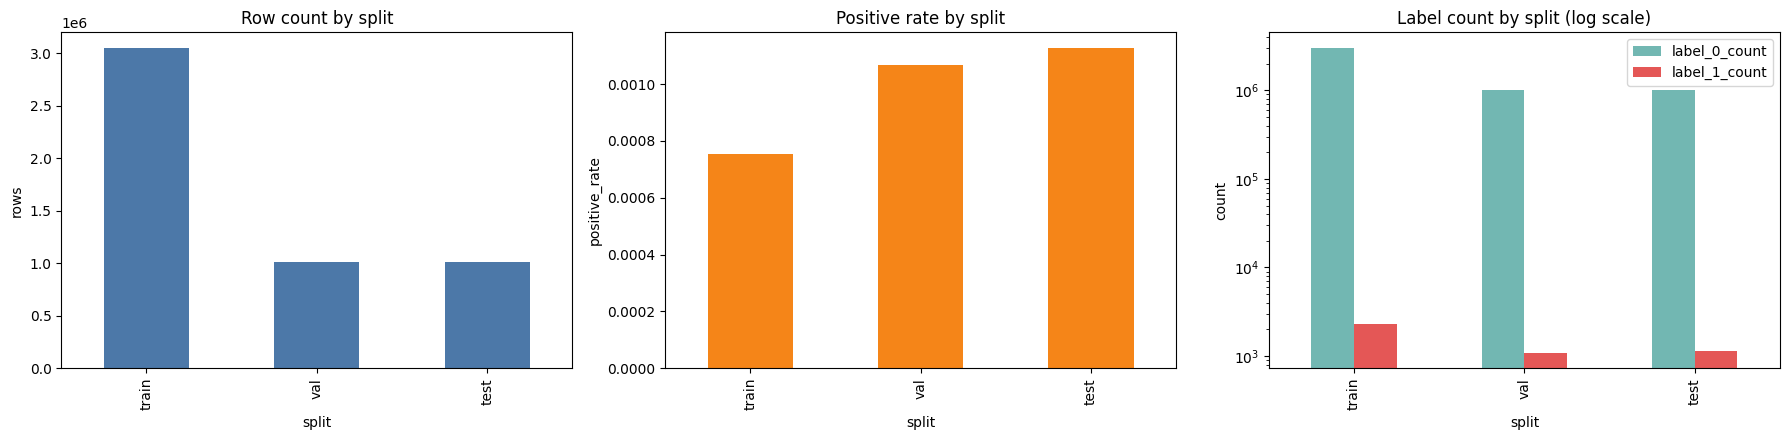

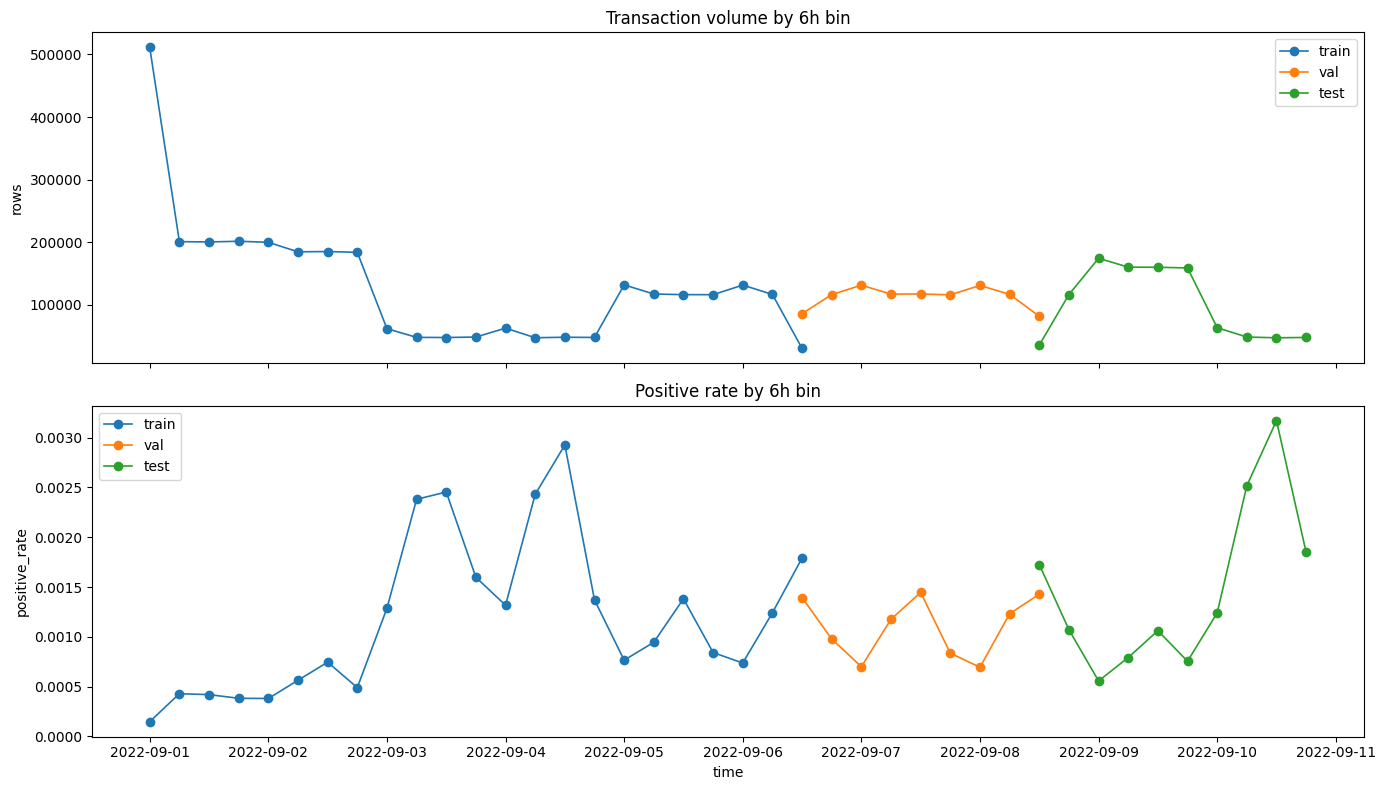

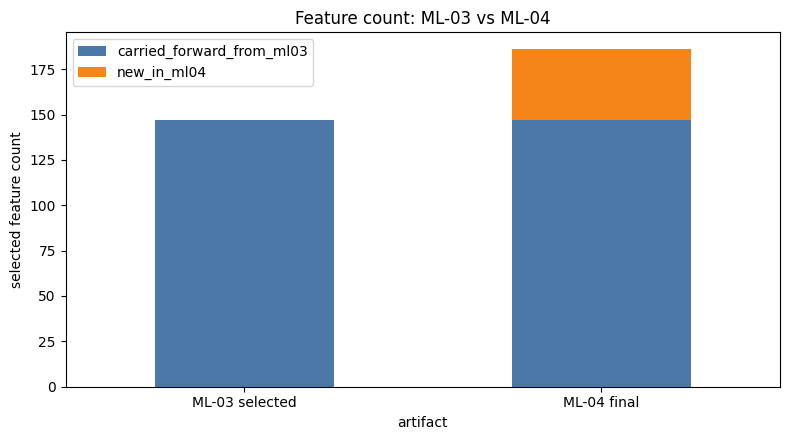

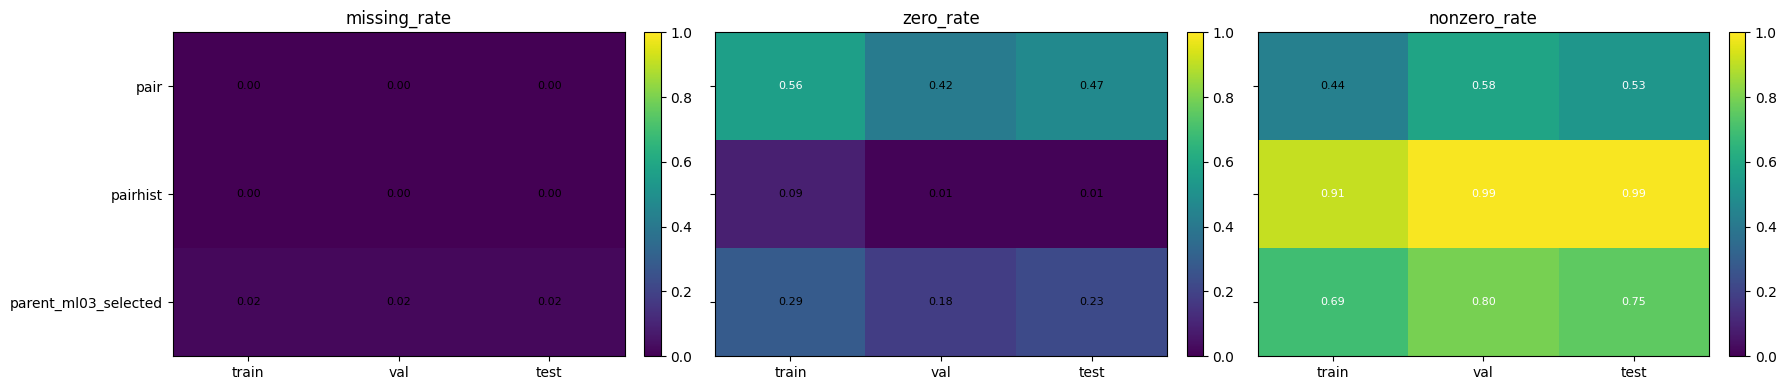

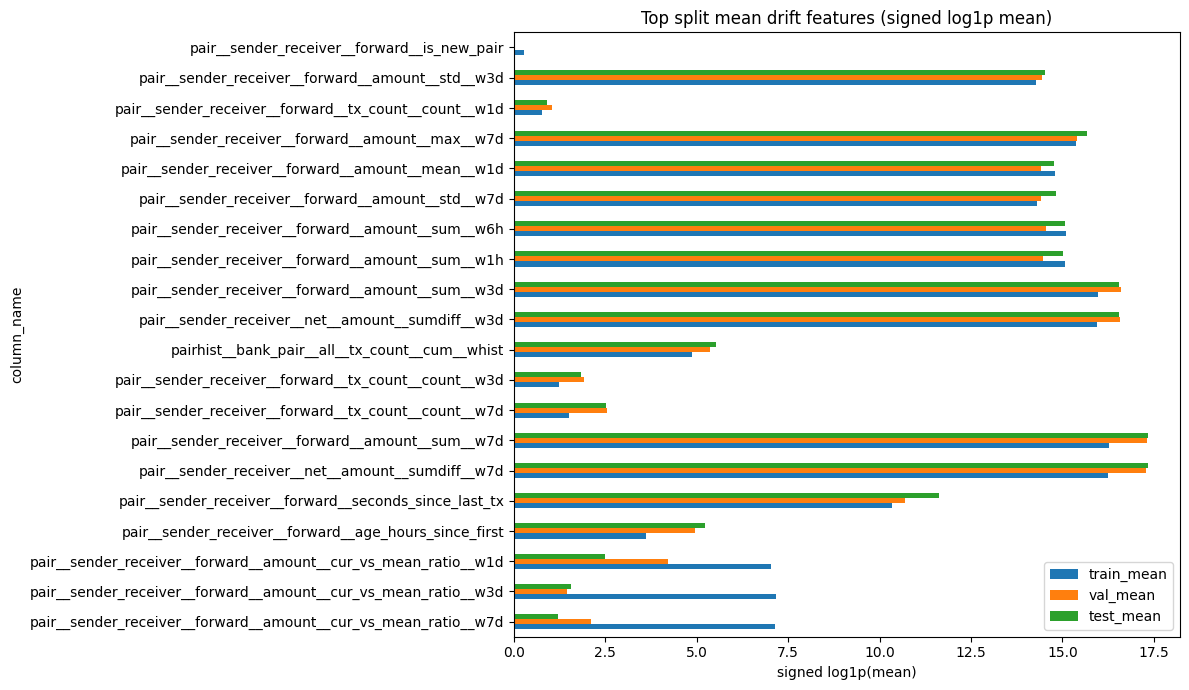

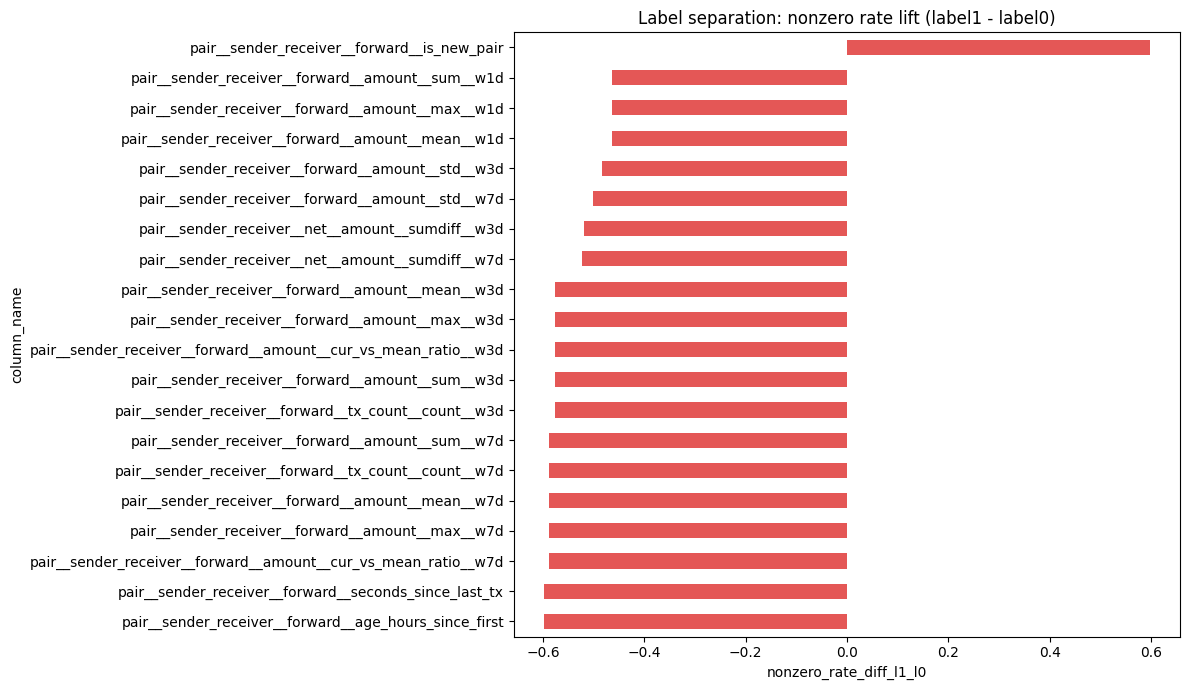

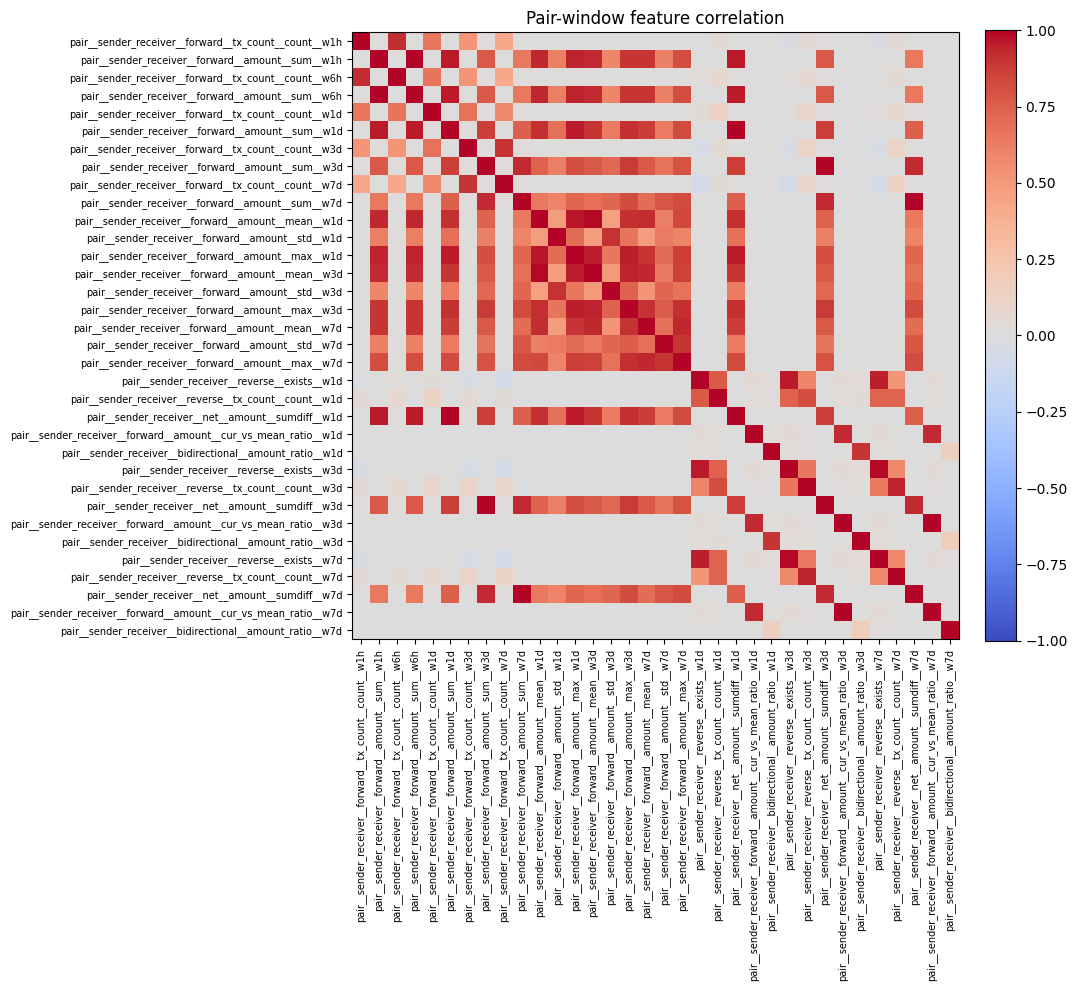

In [8]:
display(Markdown("## 8. Visual checks"))

# 8.1 split별 row count + positive rate bar, log-scale label count
split_plot_df = split_summary_exact_df.set_index("split").reindex(SPLIT_ORDER).dropna(how="all")
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
split_plot_df["rows"].plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("Row count by split")
axes[0].set_xlabel("split")
axes[0].set_ylabel("rows")
split_plot_df["positive_rate"].plot(kind="bar", ax=axes[1], color="#F58518")
axes[1].set_title("Positive rate by split")
axes[1].set_xlabel("split")
axes[1].set_ylabel("positive_rate")
split_plot_df[["label_0_count", "label_1_count"]].plot(kind="bar", ax=axes[2], color=["#72B7B2", "#E45756"])
axes[2].set_title("Label count by split (log scale)")
axes[2].set_xlabel("split")
axes[2].set_ylabel("count")
axes[2].set_yscale("log")
plt.tight_layout()
plt.show()

# 8.2 시간대별 거래량/양성률 line plot
if not time_series_df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    for split in SPLIT_ORDER:
        split_time_df = time_series_df.loc[time_series_df["split"].eq(split)]
        if split_time_df.empty:
            continue
        axes[0].plot(split_time_df["time_bin"], split_time_df["rows"], marker="o", linewidth=1.2, label=split)
        axes[1].plot(split_time_df["time_bin"], split_time_df["positive_rate"], marker="o", linewidth=1.2, label=split)
    axes[0].set_title(f"Transaction volume by {TIME_BIN_FREQ} bin")
    axes[0].set_ylabel("rows")
    axes[0].legend()
    axes[1].set_title(f"Positive rate by {TIME_BIN_FREQ} bin")
    axes[1].set_ylabel("positive_rate")
    axes[1].set_xlabel("time")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

# 8.3 ML-03 vs ML-04 feature count stacked bar
if contract_df is not None and not selected_contract_df.empty and "build_action" in selected_contract_df.columns:
    carry_forward_count = int(selected_contract_df["build_action"].astype("string").str.lower().eq("carry_forward").sum())
    build_count = int(selected_contract_df["build_action"].astype("string").str.lower().eq("build").sum())
    stage_count_df = pd.DataFrame(
        {
            "carried_forward_from_ml03": [carry_forward_count, carry_forward_count],
            "new_in_ml04": [0, build_count],
        },
        index=["ML-03 selected", "ML-04 final"],
    )
    ax = stage_count_df.plot(kind="bar", stacked=True, figsize=(8, 4.5), color=["#4C78A8", "#F58518"])
    ax.set_title("Feature count: ML-03 vs ML-04")
    ax.set_xlabel("artifact")
    ax.set_ylabel("selected feature count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# 8.4 feature group x split missing/zero/nonzero heatmap
if not group_split_quality_df.empty:
    metrics = ["missing_rate", "zero_rate", "nonzero_rate"]
    fig, axes = plt.subplots(1, 3, figsize=(18, max(4, len(groups) * 0.45)), sharey=True)
    for ax, metric in zip(axes, metrics):
        pivot = group_split_quality_df.pivot(index="feature_group", columns="split", values=metric).reindex(index=groups, columns=SPLIT_ORDER)
        im = ax.imshow(pivot.to_numpy(dtype=float), aspect="auto", cmap="viridis", vmin=0, vmax=1)
        ax.set_title(metric)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                value = pivot.iloc[i, j]
                if pd.notna(value):
                    ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if value > 0.5 else "black", fontsize=8)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# 8.5 신규 피처 train/val/test mean drift top N bar
if not review_split_df.empty:
    drift_top = review_split_df.sort_values("max_abs_signed_log1p_mean_gap_vs_train", ascending=False).head(min(TOP_N, 20))
    plot_df = drift_top.set_index("column_name")[["train_mean", "val_mean", "test_mean"]].apply(lambda col: np.sign(col) * np.log1p(np.abs(col)), axis=0)
    ax = plot_df.plot(kind="barh", figsize=(12, max(5, len(drift_top) * 0.35)))
    ax.set_title("Top split mean drift features (signed log1p mean)")
    ax.set_xlabel("signed log1p(mean)")
    ax.set_ylabel("column_name")
    plt.tight_layout()
    plt.show()

# 8.6 label별 nonzero rate lift bar
if not review_label_df.empty:
    lift_top = review_label_df.reindex(review_label_df["nonzero_rate_diff_l1_l0"].abs().sort_values(ascending=False).index).head(min(TOP_N, 20))
    ax = lift_top.sort_values("nonzero_rate_diff_l1_l0").plot(
        x="column_name",
        y="nonzero_rate_diff_l1_l0",
        kind="barh",
        legend=False,
        figsize=(12, max(5, len(lift_top) * 0.35)),
        color="#E45756",
    )
    ax.set_title("Label separation: nonzero rate lift (label1 - label0)")
    ax.set_xlabel("nonzero_rate_diff_l1_l0")
    ax.set_ylabel("column_name")
    plt.tight_layout()
    plt.show()

# 8.7 신규 pair window 간 correlation heatmap
if not corr_df.empty:
    fig, ax = plt.subplots(figsize=(max(9, len(corr_df) * 0.32), max(8, len(corr_df) * 0.32)))
    im = ax.imshow(corr_df.to_numpy(), cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title("Pair-window feature correlation")
    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_yticks(range(len(corr_df.index)))
    ax.set_xticklabels(corr_df.columns, rotation=90, fontsize=7)
    ax.set_yticklabels(corr_df.index, fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


## 9. Targeted pair feature label plots

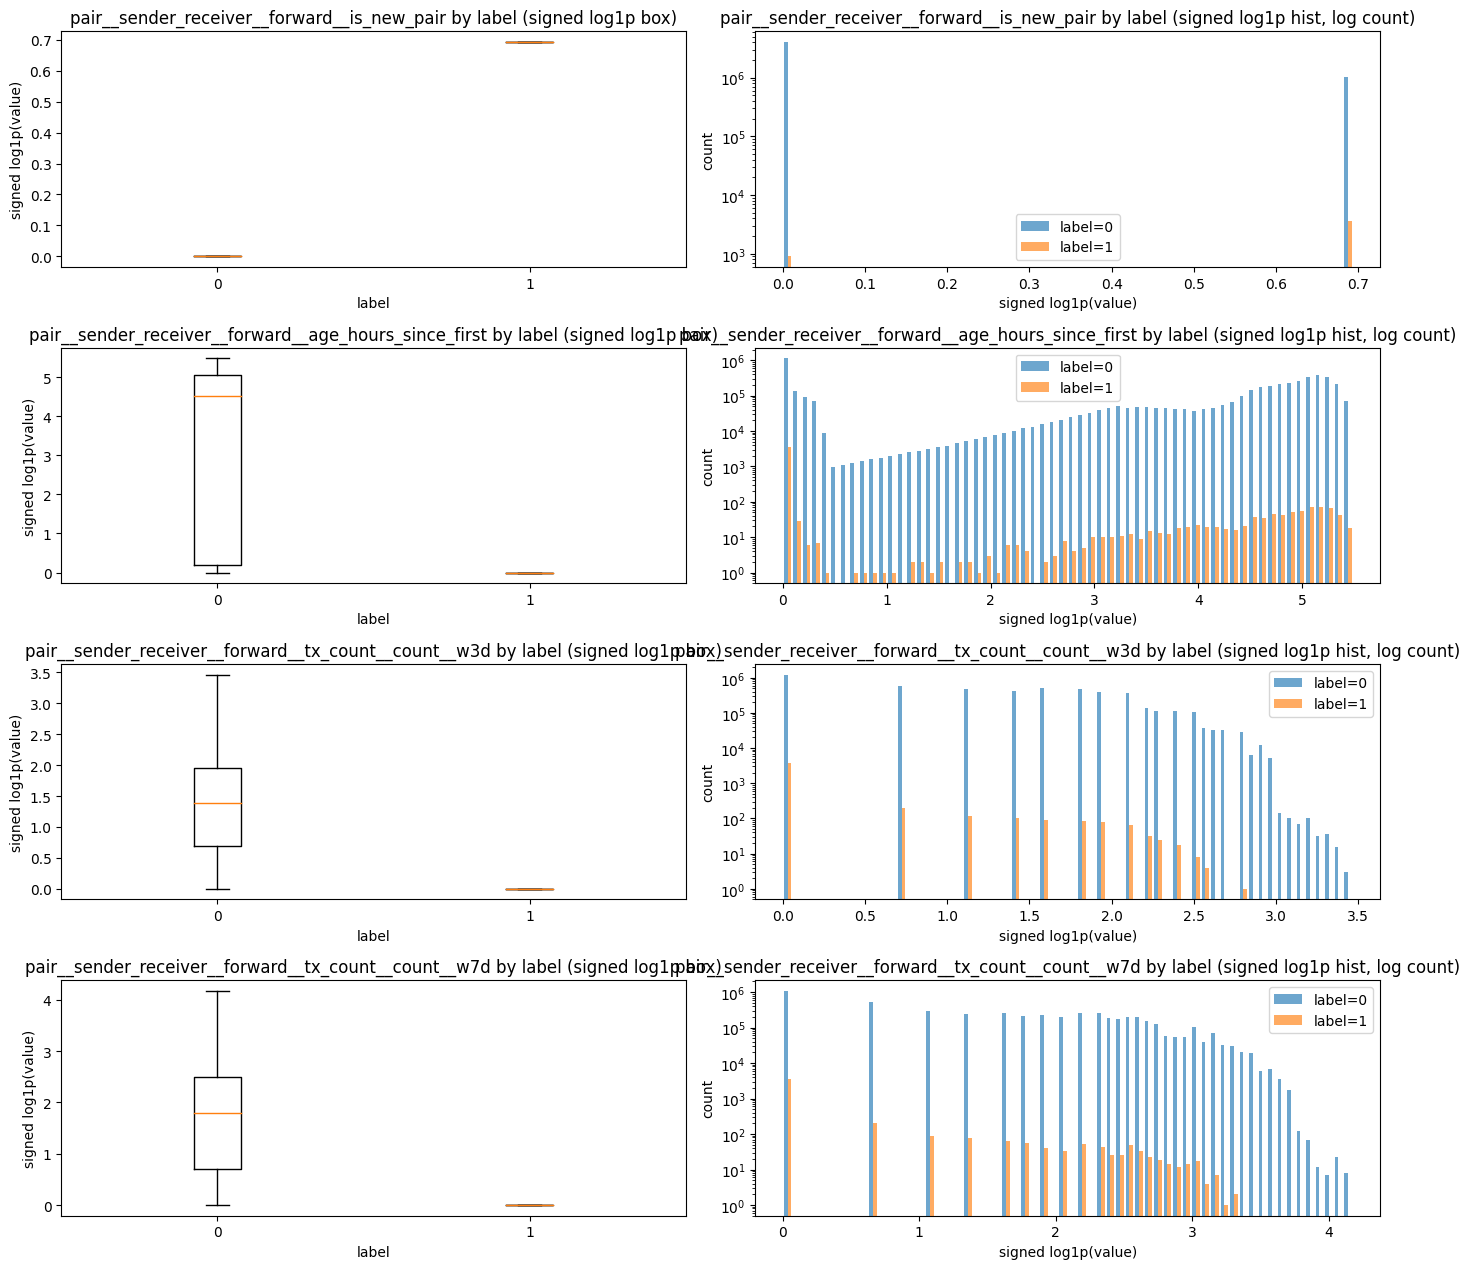

In [9]:
display(Markdown("## 9. Targeted pair feature label plots"))

def find_feature_by_suffix_or_contains(candidates: list[str], patterns: list[str]) -> Optional[str]:
    for pattern in patterns:
        for col in candidates:
            if pattern in col:
                return col
    return None

pair_plot_features = []
for patterns in [
    ["forward__is_new_pair"],
    ["forward__age_hours_since_first"],
    ["forward__tx_count__count__w3d"],
    ["forward__tx_count__count__w7d"],
]:
    matched = find_feature_by_suffix_or_contains(review_feature_columns, patterns)
    if matched is not None:
        pair_plot_features.append(matched)
pair_plot_features = list(dict.fromkeys(pair_plot_features))

if not pair_plot_features:
    display(Markdown("대상 pair feature를 찾지 못했습니다."))
else:
    plot_df = pq.read_table(target_path, columns=[label_col, *pair_plot_features]).to_pandas()
    plot_df[label_col] = pd.to_numeric(plot_df[label_col], errors="coerce").fillna(-1).astype("int8")
    for col in pair_plot_features:
        plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce").replace([np.inf, -np.inf], np.nan)

    fig, axes = plt.subplots(len(pair_plot_features), 2, figsize=(14, max(4, len(pair_plot_features) * 3.2)))
    axes = np.atleast_2d(axes)
    for row_idx, col in enumerate(pair_plot_features):
        values_by_label = [plot_df.loc[plot_df[label_col].eq(label), col].dropna().to_numpy() for label in LABEL_ORDER]
        transformed_by_label = [signed_log1p_array(values) for values in values_by_label]

        axes[row_idx, 0].boxplot(transformed_by_label, labels=[str(label) for label in LABEL_ORDER], showfliers=False)
        axes[row_idx, 0].set_title(f"{col} by label (signed log1p box)")
        axes[row_idx, 0].set_xlabel(label_col)
        axes[row_idx, 0].set_ylabel("signed log1p(value)")

        axes[row_idx, 1].hist(
            transformed_by_label,
            bins=60,
            label=[f"label={label}" for label in LABEL_ORDER],
            alpha=0.65,
            log=True,
        )
        axes[row_idx, 1].set_title(f"{col} by label (signed log1p hist, log count)")
        axes[row_idx, 1].set_xlabel("signed log1p(value)")
        axes[row_idx, 1].set_ylabel("count")
        axes[row_idx, 1].legend()
    plt.tight_layout()
    plt.show()


In [10]:
display(Markdown("## 10. Review checklist"))

issues = []
if missing_feature_columns:
    issues.append({"severity": "error", "check": "feature_list_vs_parquet", "detail": f"{len(missing_feature_columns)} feature columns are absent from parquet"})
if forbidden_selected:
    issues.append({"severity": "error", "check": "forbidden_feature_patterns", "detail": f"Selected feature list includes forbidden columns: {forbidden_selected}"})
if contract_df is None:
    issues.append({"severity": "warning", "check": "contract", "detail": "No contract artifact was loaded"})
if encoding_manifest is None:
    issues.append({"severity": "info", "check": "encoding_manifest", "detail": "No encoding manifest was loaded"})
if feature_types is None:
    issues.append({"severity": "info", "check": "feature_types", "detail": "No feature_types artifact was loaded"})

if not feature_quality_df.empty:
    inf_rows = feature_quality_df[feature_quality_df["inf_count"].fillna(0) > 0]
    if len(inf_rows) > 0:
        issues.append({"severity": "error", "check": "feature_inf", "detail": f"{len(inf_rows)} review feature columns contain +/-inf"})
    high_missing = feature_quality_df[feature_quality_df["missing_rate"].fillna(0) >= 0.5]
    if len(high_missing) > 0:
        issues.append({"severity": "warning", "check": "feature_missing_rate", "detail": f"{len(high_missing)} review feature columns have missing_rate >= 0.5"})

if not split_summary_exact_df.empty:
    zero_positive_splits = split_summary_exact_df.loc[split_summary_exact_df["label_1_count"].fillna(0).eq(0), "split"].tolist()
    if zero_positive_splits:
        issues.append({"severity": "error", "check": "split_positive_label", "detail": f"No positive label rows in split(s): {zero_positive_splits}"})

issue_df = pd.DataFrame(issues) if issues else pd.DataFrame([{"severity": "ok", "check": "full_artifact_review", "detail": "No blocking issue detected by exact notebook checks"}])
display(issue_df)

display(Markdown("### Suggested manual checks"))
display(
    pd.DataFrame(
        [
            {"check": "누수", "detail": "신규 feature의 leakage_policy 또는 생성 로직이 timestamp < current_timestamp 원칙을 지키는지 확인한다."},
            {"check": "승인", "detail": "ML 학습에는 fb_outputs 후보가 아니라 승인된 ml_inputs contract의 used_in_ml=True 컬럼만 사용한다."},
            {"check": "drift", "detail": "split drift가 큰 피처는 시간 누적 효과인지, 분할 경계 문제인지, 모델 안정성 리스크인지 구분한다."},
            {"check": "label separation", "detail": "label separation이 과도하게 큰 피처는 도메인상 자연스러운 신규성/반복성 신호인지 누수 의심 신호인지 별도 검토한다."},
        ]
    )
)


## 10. Review checklist

,severity,check,detail
0,ok,full_artifact_review,No blocking issue detected by exact notebook checks


### Suggested manual checks

,check,detail
0,누수,신규 feature의 leakage_policy 또는 생성 로직이 timestamp < current_timestamp 원칙을 지키는지 확인한다.
1,승인,ML 학습에는 fb_outputs 후보가 아니라 승인된 ml_inputs contract의 used_in_ml=True 컬럼만 사용한다.
2,drift,"split drift가 큰 피처는 시간 누적 효과인지, 분할 경계 문제인지, 모델 안정성 리스크인지 구분한다."
3,label separation,label separation이 과도하게 큰 피처는 도메인상 자연스러운 신규성/반복성 신호인지 누수 의심 신호인지 별도 검토한다.
